In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causaldata import nhefs

df = nhefs.load_pandas().data
print(f"Total subjects: {len(df)}")
print(f"\nDeath-related columns:")
print(df[['death', 'yrdth', 'modth', 'dadth']].head(10))
print(f"\nDeath indicator distribution:")
print(df['death'].value_counts(dropna=False))
print(f"\nYear of death (yrdth) — non-null only:")
print(df['yrdth'].dropna().describe().round(1))

Total subjects: 1629

Death-related columns:
   death  yrdth  modth  dadth
0    0.0    NaN    NaN    NaN
1    0.0    NaN    NaN    NaN
2    0.0    NaN    NaN    NaN
3    1.0   85.0    2.0   14.0
4    0.0    NaN    NaN    NaN
5    0.0    NaN    NaN    NaN
6    0.0    NaN    NaN    NaN
7    0.0    NaN    NaN    NaN
8    1.0   84.0   10.0   13.0
9    1.0   86.0   10.0   17.0

Death indicator distribution:
death
0.0    1311
1.0     318
Name: count, dtype: int64

Year of death (yrdth) — non-null only:
count    318.0
mean      87.6
std        2.7
min       83.0
25%       85.0
50%       88.0
75%       90.0
max       92.0
Name: yrdth, dtype: float64


In [2]:
# Build (time, event) columns following Hernán-Robins Chapter 17 convention
df['surv_time'] = np.where(
    (df['death'] == 1) & df['yrdth'].notna(),
    (df['yrdth'] - 83) * 12 + df['modth'],   # months from Jan 1983 to death
    120                                       # end of follow-up (Dec 1992)
)
df['surv_event'] = df['death'].fillna(0).astype(int)

# Sanity-check: time and event align
print("Survival time distribution by event status:")
print(df.groupby('surv_event')['surv_time'].describe().round(1))
print(f"\nEvent rate: {df['surv_event'].mean():.1%}")

# Quick view of the first few constructed rows
cols = ['death', 'yrdth', 'modth', 'surv_time', 'surv_event']
print(f"\nFirst 10 rows of survival construction:")
print(df[cols].head(10))

Survival time distribution by event status:
             count   mean   std    min    25%    50%    75%    max
surv_event                                                        
0           1311.0  120.0   0.0  120.0  120.0  120.0  120.0  120.0
1            318.0   61.1  31.9    1.0   35.0   61.0   86.8  120.0

Event rate: 19.5%

First 10 rows of survival construction:
   death  yrdth  modth  surv_time  surv_event
0    0.0    NaN    NaN      120.0           0
1    0.0    NaN    NaN      120.0           0
2    0.0    NaN    NaN      120.0           0
3    1.0   85.0    2.0       26.0           1
4    0.0    NaN    NaN      120.0           0
5    0.0    NaN    NaN      120.0           0
6    0.0    NaN    NaN      120.0           0
7    0.0    NaN    NaN      120.0           0
8    1.0   84.0   10.0       22.0           1
9    1.0   86.0   10.0       46.0           1


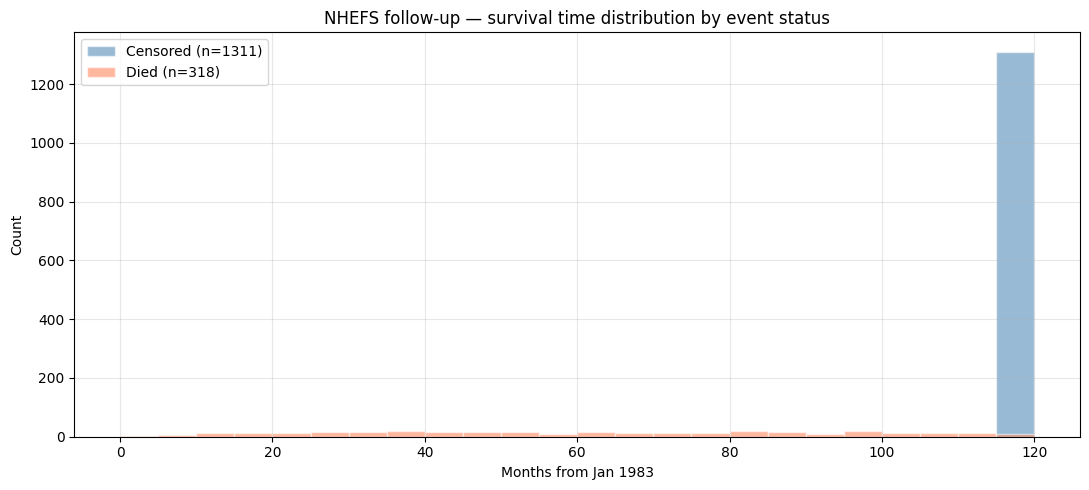

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.arange(0, 125, 5)

ax.hist(df.loc[df['surv_event']==0, 'surv_time'], bins=bins,
        alpha=0.55, label=f'Censored (n={(df["surv_event"]==0).sum()})',
        color='steelblue', edgecolor='white')
ax.hist(df.loc[df['surv_event']==1, 'surv_time'], bins=bins,
        alpha=0.55, label=f'Died (n={(df["surv_event"]==1).sum()})',
        color='coral', edgecolor='white')

ax.set_xlabel('Months from Jan 1983')
ax.set_ylabel('Count')
ax.set_title('NHEFS follow-up — survival time distribution by event status')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Survival analytic sample: 1629 subjects, 318 deaths


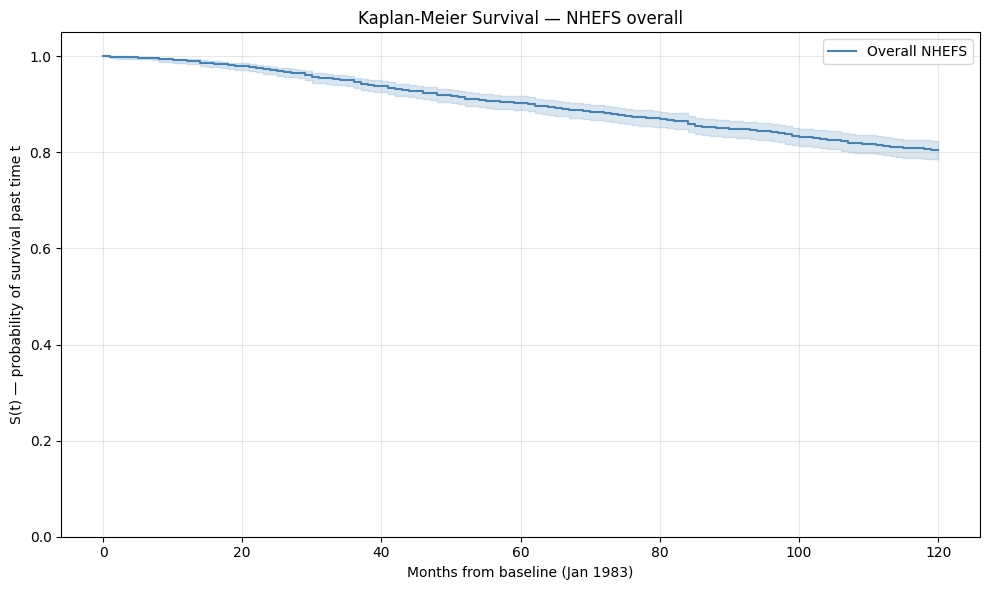


5-year (60-month) survival:  0.904
10-year (120-month) survival: 0.805
Median survival time: inf  (inf means >50% alive at follow-up end)


In [4]:
from lifelines import KaplanMeierFitter

# Clean: drop any NaN in qsmk to keep the analytic sample consistent
surv = df[['qsmk', 'surv_time', 'surv_event']].dropna(subset=['qsmk']).copy()
surv['qsmk'] = surv['qsmk'].astype(int)
print(f"Survival analytic sample: {len(surv)} subjects, {surv['surv_event'].sum()} deaths")

# Overall KM
kmf = KaplanMeierFitter()
kmf.fit(durations=surv['surv_time'], event_observed=surv['surv_event'],
        label='Overall NHEFS')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, color='steelblue', ci_alpha=0.2)
ax.set_xlabel('Months from baseline (Jan 1983)')
ax.set_ylabel('S(t) — probability of survival past time t')
ax.set_title('Kaplan-Meier Survival — NHEFS overall')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Key landmarks
print(f"\n5-year (60-month) survival:  {kmf.survival_function_at_times(60).values[0]:.3f}")
print(f"10-year (120-month) survival: {kmf.survival_function_at_times(120).values[0]:.3f}")
print(f"Median survival time: {kmf.median_survival_time_}  (inf means >50% alive at follow-up end)")

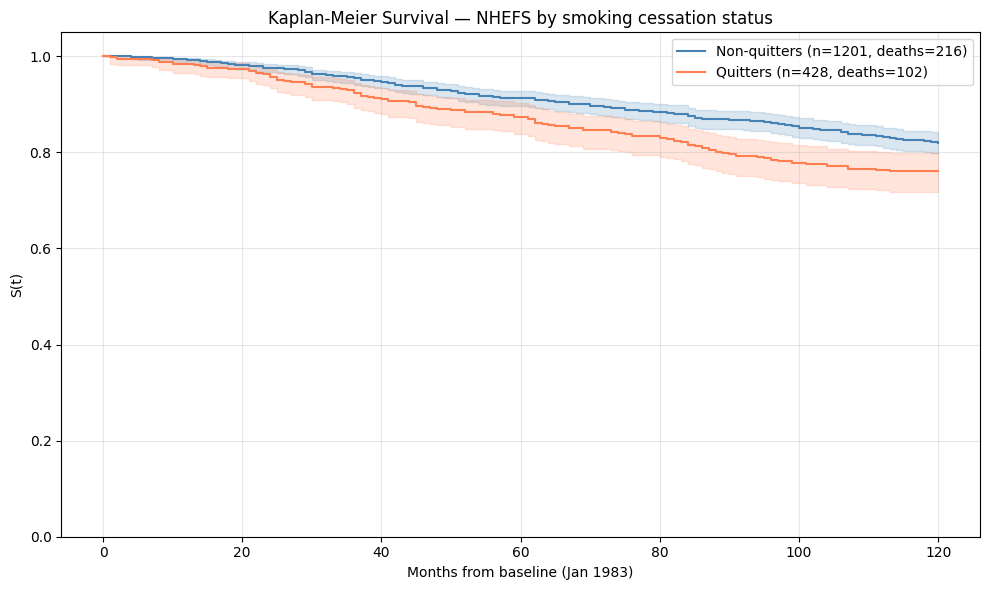

Log-rank χ² statistic: 7.733
Log-rank p-value:       0.005421


In [5]:
from lifelines.statistics import logrank_test

fig, ax = plt.subplots(figsize=(10, 6))
for qsmk_val, label, color in [(0, 'Non-quitters', 'steelblue'),
                               (1, 'Quitters',      'coral')]:
    sub = surv[surv['qsmk'] == qsmk_val]
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(durations=sub['surv_time'], event_observed=sub['surv_event'],
              label=f'{label} (n={len(sub)}, deaths={sub["surv_event"].sum()})')
    kmf_g.plot_survival_function(ax=ax, color=color, ci_alpha=0.2)

ax.set_xlabel('Months from baseline (Jan 1983)')
ax.set_ylabel('S(t)')
ax.set_title('Kaplan-Meier Survival — NHEFS by smoking cessation status')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Log-rank test
q  = surv[surv['qsmk'] == 1]
nq = surv[surv['qsmk'] == 0]
lr = logrank_test(
    durations_A     = q['surv_time'],
    durations_B     = nq['surv_time'],
    event_observed_A= q['surv_event'],
    event_observed_B= nq['surv_event'],
)
print(f"Log-rank χ² statistic: {lr.test_statistic:.3f}")
print(f"Log-rank p-value:       {lr.p_value:.6f}")

In [6]:
from lifelines import CoxPHFitter

# Build the survival modeling dataset — same confounders as causal
cph_data = df[['surv_time', 'surv_event', 'qsmk',
               'age', 'sex', 'race', 'education',
               'smokeintensity', 'smokeyrs',
               'exercise', 'active', 'wt71']].dropna().copy()

# Cast categoricals to integer codes
for col in ['sex', 'race', 'education', 'exercise', 'active']:
    if cph_data[col].dtype.name == 'category':
        cph_data[col] = cph_data[col].astype(int)
cph_data['qsmk'] = cph_data['qsmk'].astype(int)

print(f"Cox PH sample: {len(cph_data)} subjects, {cph_data['surv_event'].sum()} deaths")

# Fit Cox PH
cph = CoxPHFitter()
cph.fit(cph_data, duration_col='surv_time', event_col='surv_event')
cph.print_summary(decimals=3)

# Headline: the qsmk hazard ratio
qsmk_hr  = np.exp(cph.params_['qsmk'])
qsmk_ci_lo, qsmk_ci_hi = np.exp(cph.confidence_intervals_.loc['qsmk'].values)
qsmk_p   = cph.summary.loc['qsmk', 'p']

print(f"\n{'='*55}")
print(f"HEADLINE: Adjusted HR for smoking cessation (qsmk)")
print(f"{'='*55}")
print(f"  HR = {qsmk_hr:.3f}")
print(f"  95% CI: [{qsmk_ci_lo:.3f}, {qsmk_ci_hi:.3f}]")
print(f"  p-value: {qsmk_p:.4f}")
print(f"\nUnadjusted (log-rank): χ² = 7.73, p = 0.0054, quitters worse")

Cox PH sample: 1629 subjects, 318 deaths


<lifelines.CoxPHFitter: fitted with 1629 total observations, 1311 right-censored observations>
             duration col = 'surv_time'
                event col = 'surv_event'
      baseline estimation = breslow
   number of observations = 1629
number of events observed = 318
   partial log-likelihood = -2099.747
         time fit was run = 2026-05-17 02:36:29 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
qsmk            0.034     1.035     0.124          -0.209           0.278               0.811               1.320
age             0.079     1.082     0.009           0.062           0.095               1.064               1.100
sex            -0.366     0.693     0.136          -0.633          -0.100               0.531               0.905
race            0.136     1.146     0.167          -0.192           0.464               0.825               1.591
education      -0.142     0.867     0.052          -0.244          -0.040               0.783               0.961
smokeintensity  0.006     1.006     0.005          -0.004           0.016               0.996               1.016
smokeyrs        0.020     1.020     0.008           0.004           0.035               1.004               1.036
exercise        0.117     1.124     0.085          -0.050           0.284               0.951               1.329
active          0.116     1.123     0.087          -0.054           0.286               0.948               1.332
wt71            0.002     1.002     0.004          -0.006           0.010               0.994               1.010

                cmp to      z       p  -log2(p)
covariate                                      
qsmk             0.000  0.276   0.782     0.354
age              0.000  9.116 <0.0005    63.472
sex              0.000 -2.692   0.007     7.138
race             0.000  0.812   0.417     1.263
education        0.000 -2.731   0.006     7.309
smokeintensity   0.000  1.182   0.237     2.077
smokeyrs         0.000  2.477   0.013     6.236
exercise         0.000  1.371   0.170     2.554
active           0.000  1.342   0.180     2.477
wt71             0.000  0.511   0.609     0.715
---
Concordance = 0.805
Partial AIC = 4219.494
log-likelihood ratio test = 437.838 on 10 df
-log2(p) of ll-ratio test = 289.295


HEADLINE: Adjusted HR for smoking cessation (qsmk)
  HR = 1.035
  95% CI: [0.811, 1.320]
  p-value: 0.7823

Unadjusted (log-rank): χ² = 7.73, p = 0.0054, quitters worse


PROPORTIONAL HAZARDS ASSUMPTION — Schoenfeld residuals

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


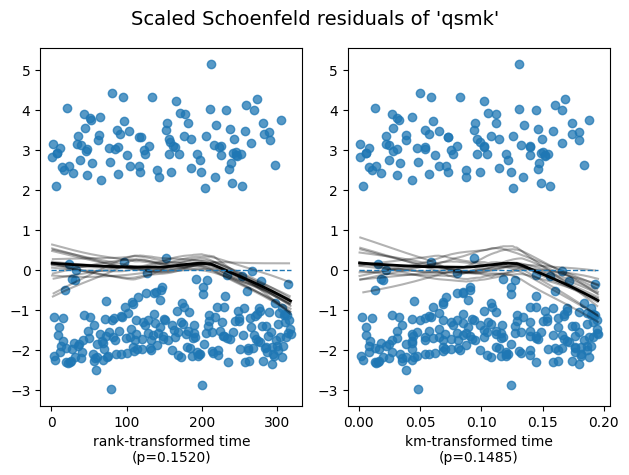

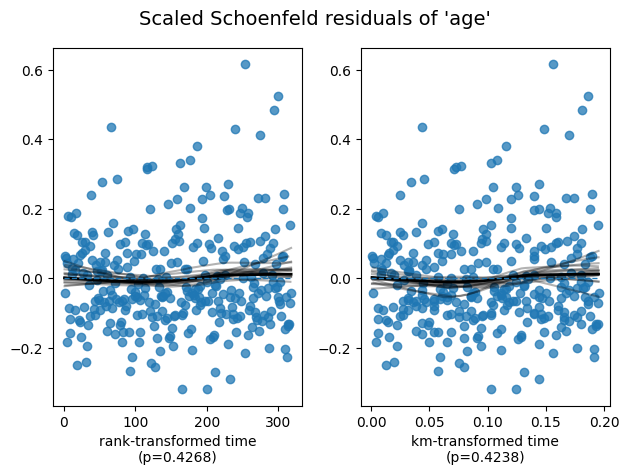

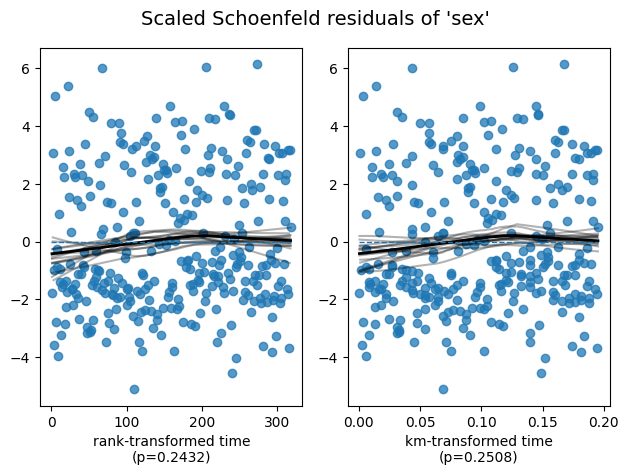

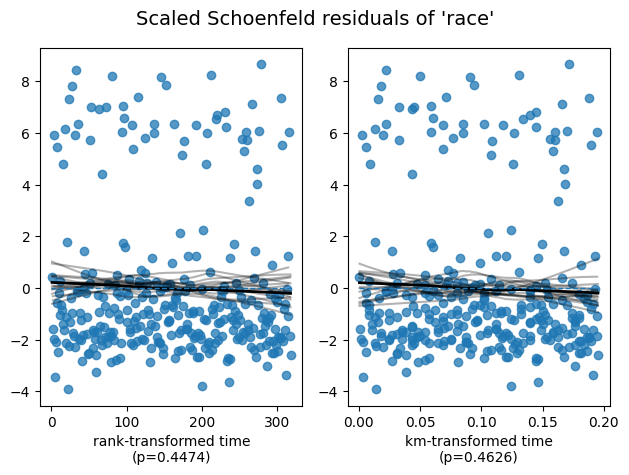

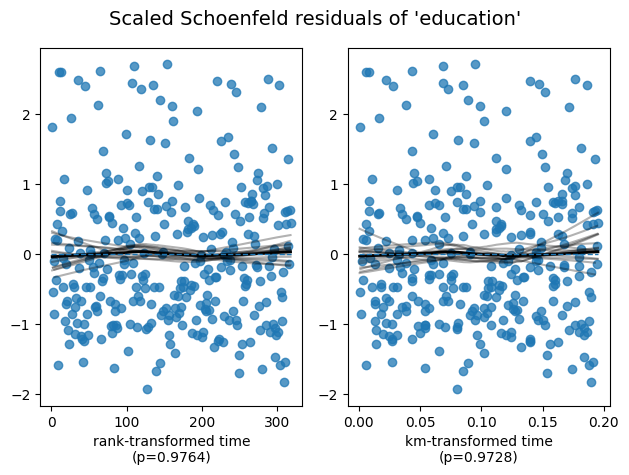

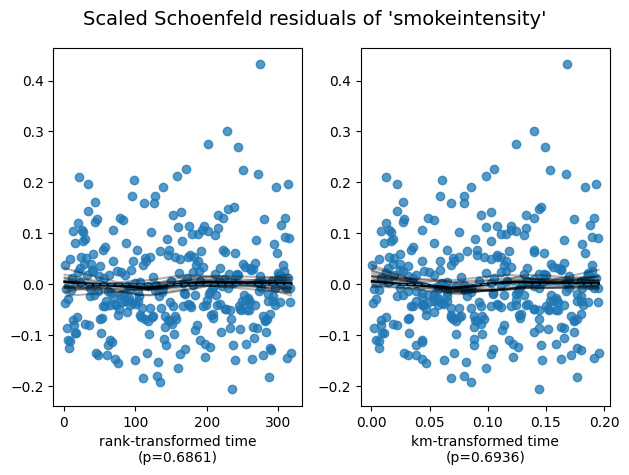

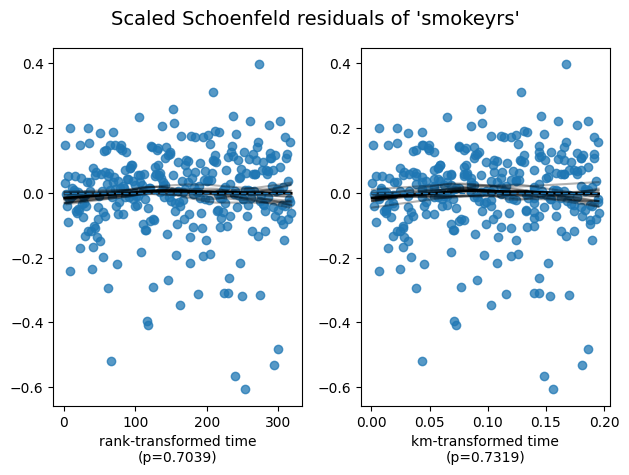

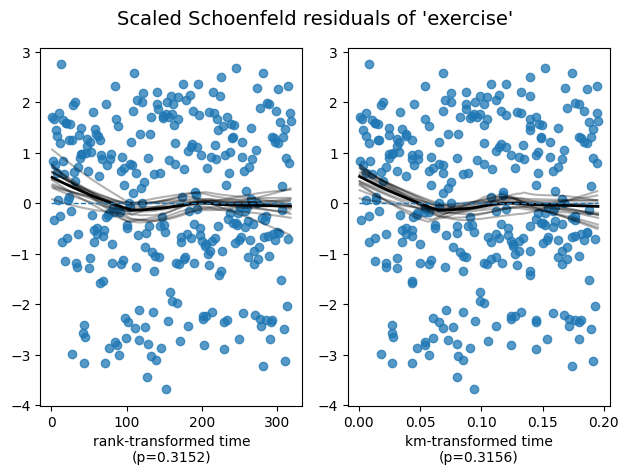

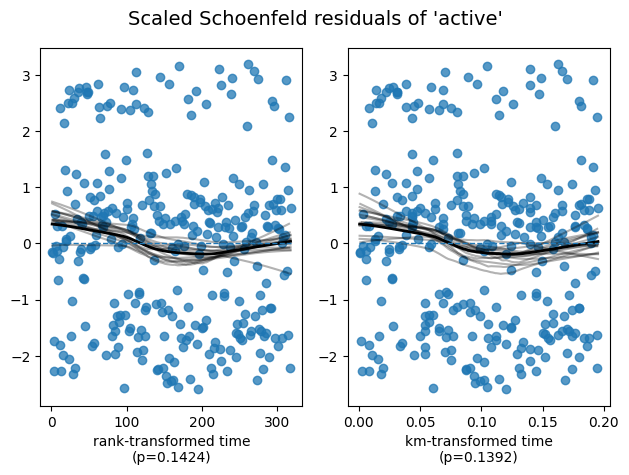

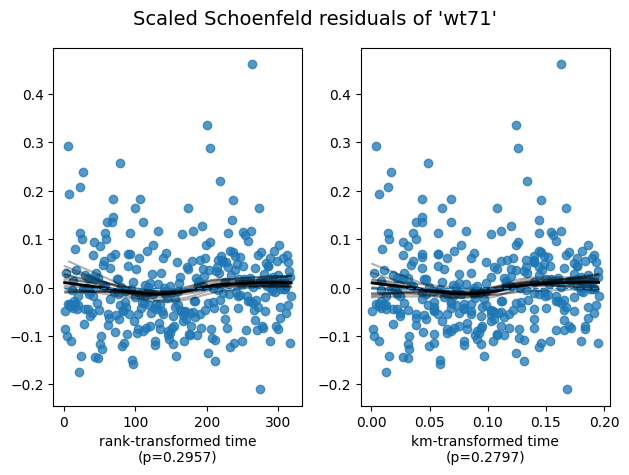

In [7]:
print("=" * 60)
print("PROPORTIONAL HAZARDS ASSUMPTION — Schoenfeld residuals")
print("=" * 60)

# This prints per-covariate test results and renders diagnostic plots
results = cph.check_assumptions(cph_data,
                                p_value_threshold=0.05,
                                show_plots=True)

In [8]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split

# scikit-survival needs a structured array for y
y_struct = np.array(
    list(zip(cph_data['surv_event'].astype(bool),
             cph_data['surv_time'].astype(float))),
    dtype=[('event', '?'), ('time', '<f8')]
)
X = cph_data[['qsmk', 'age', 'sex', 'race', 'education',
              'smokeintensity', 'smokeyrs', 'exercise', 'active', 'wt71']]

# Stratified split on event status to balance events across train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_struct, test_size=0.25, random_state=42,
    stratify=y_struct['event']
)
print(f"Train: n={len(X_tr)}, events={y_tr['event'].sum()}")
print(f"Test:  n={len(X_te)}, events={y_te['event'].sum()}")

# --- Refit Cox PH on train only (for fair test-set comparison) ---
cox_tr = X_tr.copy()
cox_tr['surv_time']  = y_tr['time']
cox_tr['surv_event'] = y_tr['event'].astype(int)
cph_compare = CoxPHFitter()
cph_compare.fit(cox_tr, duration_col='surv_time', event_col='surv_event')

cox_risk_te = cph_compare.predict_partial_hazard(X_te).values
cox_c = concordance_index_censored(
    y_te['event'], y_te['time'], cox_risk_te
)[0]

# --- Fit RSF on the same train ---
rsf = RandomSurvivalForest(
    n_estimators     = 200,
    min_samples_split= 10,
    min_samples_leaf = 15,
    max_features     = 'sqrt',
    n_jobs           = -1,
    random_state     = 42,
)
rsf.fit(X_tr, y_tr)

rsf_risk_te = rsf.predict(X_te)
rsf_c = concordance_index_censored(
    y_te['event'], y_te['time'], rsf_risk_te
)[0]

print(f"\n{'='*55}")
print("MODEL COMPARISON — held-out 25% test set")
print('='*55)
print(f"  Cox PH concordance:               {cox_c:.3f}")
print(f"  Random Survival Forest concordance:{rsf_c:.3f}")
print(f"  Cox PH (train, full sample):       0.805 [for reference]")

Train: n=1221, events=238
Test:  n=408, events=80

MODEL COMPARISON — held-out 25% test set
  Cox PH concordance:               0.802
  Random Survival Forest concordance:0.804
  Cox PH (train, full sample):       0.805 [for reference]


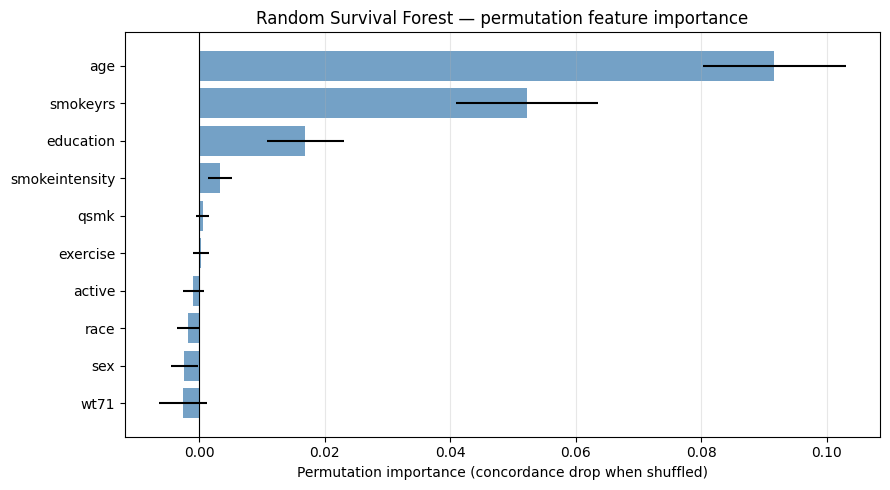

          feature  importance     std
1             age      0.0916  0.0114
6        smokeyrs      0.0522  0.0113
4       education      0.0169  0.0062
5  smokeintensity      0.0033  0.0019
0            qsmk      0.0005  0.0010
7        exercise      0.0003  0.0013
8          active     -0.0010  0.0016
3            race     -0.0017  0.0018
2             sex     -0.0024  0.0022
9            wt71     -0.0026  0.0038


In [9]:
from sklearn.inspection import permutation_importance

# Permutation importance — concordance drop when each feature is shuffled
perm = permutation_importance(
    rsf, X_te, y_te,
    n_repeats   = 10,
    random_state= 42,
    n_jobs      = -1,
)

importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df['feature'], importance_df['importance'],
        xerr=importance_df['std'], color='steelblue', alpha=0.75)
ax.set_xlabel('Permutation importance (concordance drop when shuffled)')
ax.set_title('Random Survival Forest — permutation feature importance')
ax.grid(alpha=0.3, axis='x')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(importance_df.sort_values('importance', ascending=False).round(4))